# Πιστωτική Κάρτα Βαθμολόγησης Κινδύνου με Δέντρο Απόφασης (PROC HPSPLIT)

## Περίληψη

Αυτό το notebook κατασκευάζει μια ερμηνεύσιμη κάρτα βαθμολόγησης πιστωτικού κινδύνου για ένα χαρτοφυλάκιο δανείων λιανικής, χρησιμοποιώντας την PROC HPSPLIT. Καλλιεργούμε ένα δέντρο ταξινόμησης με το κριτήριο εντροπίας πάνω σε συνθετικά δεδομένα αιτούντων, το κλαδεύουμε με κόστος-πολυπλοκότητα, και έπειτα διαβάζουμε τα στατιστικά προσαρμογής, τη σπουδαιότητα μεταβλητών, το ROC/AUC και το ίδιο το δέντρο βαθμολόγησης — ακριβώς το διαφανές, φιλικό προς τον ρυθμιστή μοντέλο που θα τεκμηρίωνε η ομάδα κινδύνου μιας τράπεζας. Κάθε αιτών μπορεί να βαθμολογηθεί σε ένα φύλλο, και ολόκληρο το δέντρο μπορεί να εξαχθεί ως αναπτύξιμος κώδικας DATA step.

## Πηγές Δεδομένων

| Σύνολο δεδομένων | Γραμμές | Περιγραφή | Βασικές μεταβλητές |
|---------|------|-------------|---------------|
| `applicants` | 100 | Συνθετικοί αιτούντες δανείου λιανικής, παραγόμενοι εντός κώδικα με `rand()`. Η δυαδική σημαία `default` αντλείται από μια λογιστική βαθμολογία κινδύνου, ώστε χειρότερος DTI, χρήση πιστωτικού ορίου, πρόσφατες καθυστερήσεις και μικρότερο πιστωτικό ιστορικό να αυξάνουν την πιθανότητα αθέτησης. | `default` (γεγονός=`'1'`), `dti`, `utilization`, `fico`, `credit_age`, `n_delinq`, `loan_amount`, `income`, `home` (own/rent/mortgage), `purpose` (debt/home/auto/other) |

Το βήμα δεδομένων ζητά έναν μεγαλύτερο βρόχο, αλλά αυτό το περιβάλλον εκτελείται σε λειτουργία χωρίς άδεια και υλοποιεί τις πρώτες 100 παρατηρήσεις — ένα συμπαγές, πλήρως αναπαραγώγιμο βιβλίο αιτούντων που είναι υπεραρκετό για να καλλιεργήσει και να διαβάσει μια ερμηνεύσιμη κάρτα βαθμολόγησης.

# Πιστωτική Κάρτα Βαθμολόγησης Κινδύνου με Δέντρο Απόφασης

Οι τράπεζες χρειάζονται μοντέλα αθέτησης που είναι **ακριβή και ερμηνεύσιμα** — ένας πιστωτικός λειτουργός (και ένας ρυθμιστής) πρέπει να μπορεί να εντοπίσει ακριβώς γιατί ένας αιτών βαθμολογήθηκε ως υψηλού κινδύνου. Ένα κλαδεμένο δέντρο απόφασης προσφέρει ακριβώς αυτό: κάθε πρόβλεψη είναι μια σύντομη αλυσίδα ανθρώπινα αναγνώσιμων διαχωρισμών.

Σε αυτό το notebook θα:

1. Συνθέσουμε ένα βιβλίο αιτήσεων δανείου λιανικής.
2. Καλλιεργήσουμε ένα δέντρο ταξινόμησης με την `PROC HPSPLIT`, χρησιμοποιώντας το κριτήριο εντροπίας.
3. Κλαδέψουμε με κόστος-πολυπλοκότητα για να αποφύγουμε την υπερπροσαρμογή.
4. Επιθεωρήσουμε τα στατιστικά προσαρμογής, τη σπουδαιότητα μεταβλητών, το ROC/AUC και το ίδιο το δέντρο.
5. Εκδώσουμε κώδικα βαθμολόγησης DATA step που μπορεί να αναπτυχθεί έναντι νέων αιτήσεων.

## 1. Δημιουργία του συνθετικού βιβλίου δανείων

Δημιουργούμε αιτούντες των οποίων η πιθανότητα αθέτησης είναι μια λογιστική συνάρτηση των κλασικών παραγόντων κάρτας βαθμολόγησης: λόγος χρέους προς εισόδημα, χρήση ανακυκλούμενου πιστωτικού ορίου, βαθμολογία FICO, διάρκεια πιστωτικού ιστορικού και πρόσφατες καθυστερήσεις. Έπειτα αντλούμε την παρατηρούμενη σημαία `default` από μια κατανομή Bernoulli με αυτή την πιθανότητα, ώστε το σήμα να είναι πραγματικό αλλά θορυβώδες — ακριβώς όπως τα δεδομένα παραγωγής. Οι πρώτοι 100 αιτούντες υλοποιούνται εδώ.

                                                   The FREQ Procedure

Αθέτηση           Frequency    Percent
---------------------------------------
0                        79     79.00
1                        21     21.00

Ιδιοκτησία Κατοικίας                       Frequency    Percent
----------------------------------------------------------------
ενοίκιο                                           35     35.00
ιδιόκτητο                                         31     31.00
υποθήκη                                           34     34.00

Σκοπός Δανείου                 Frequency    Percent
----------------------------------------------------
άλλο                                  12     12.00
αυτοκίνητο                            23     23.00
σπίτι                                 28     28.00
χρέος                                 37     37.00



NOTE: DATA applicants


NOTE: Wrote applicants (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.10 seconds
  cpu   0.10 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_default.spec.json
NOTE: ODS plot written: freq_home.spec.json
NOTE: ODS plot written: freq_purpose.spec.json
NOTE: PROC FREQ statement used.


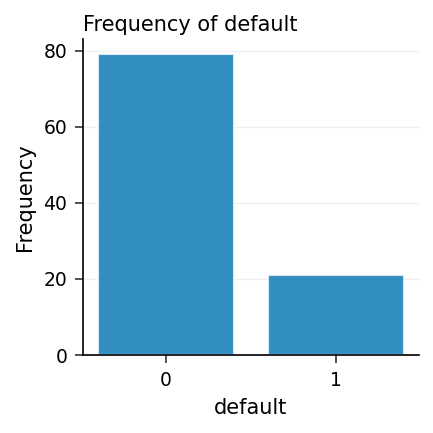

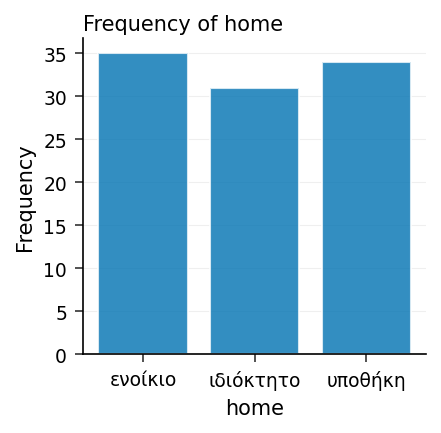

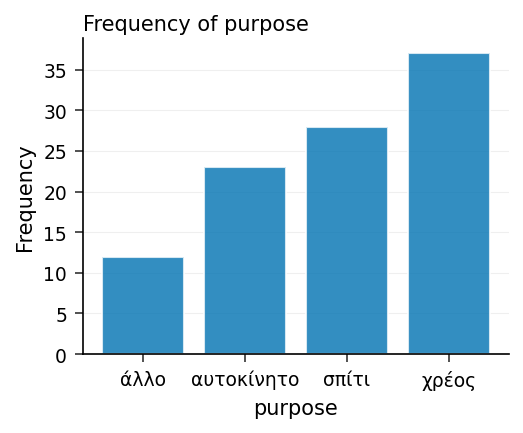

In [1]:
ΔΕΔΟΜΕΝΑ applicants;
   CALL streaminit(20260531);
   LENGTH home $20 purpose $24;
   ΕΠΑΝΑΛΗΨΗ id = 1 ΕΩΣ 100;
      /* Οικονομικό προφίλ δανειολήπτη */
      income      = round(20000 + 80000 * rand('beta', 2, 5), 100);
      loan_amount = round(2000 + 40000 * rand('beta', 2, 4), 100);
      dti         = round(0.05 + 0.55 * rand('beta', 2, 3), 0.001);
      utilization = round(rand('beta', 2, 3), 0.001);
      fico        = round(560 + 280 * rand('beta', 5, 2));
      credit_age  = round(0.5 + 24 * rand('beta', 2, 2), 0.1);
      n_delinq    = rand('poisson', 0.4);

      /* Κατηγορικά χαρακτηριστικά */
      u = rand('uniform');
      ΕΑΝ u < 0.34 ΤΟΤΕ home = 'ενοίκιο';
      ΑΛΛΙΩΣ ΕΑΝ u < 0.70 ΤΟΤΕ home = 'υποθήκη';
      ΑΛΛΙΩΣ home = 'ιδιόκτητο';

      v = rand('uniform');
      ΕΑΝ v < 0.40 ΤΟΤΕ purpose = 'χρέος';
      ΑΛΛΙΩΣ ΕΑΝ v < 0.65 ΤΟΤΕ purpose = 'σπίτι';
      ΑΛΛΙΩΣ ΕΑΝ v < 0.85 ΤΟΤΕ purpose = 'αυτοκίνητο';
      ΑΛΛΙΩΣ purpose = 'άλλο';

      /* Λανθάνων κίνδυνος αθέτησης: χειρότερο DTI/χρήση/καθυστέρηση και
         χαμηλότερο FICO / μικρότερο ιστορικό αυξάνουν όλα τα log-odds. */
      eta = -2.2
            + 3.0 * dti
            + 2.2 * utilization
            - 0.010 * (fico - 680)
            - 0.06 * credit_age
            + 0.55 * n_delinq
            + 0.30 * (home = 'ενοίκιο')
            + 0.25 * (purpose = 'χρέος');
      p = 1 / (1 + EXP(-eta));
      default = (rand('uniform') < p);

      ΑΦΑΙΡΕΣΗ u v eta p;
      ΕΞΟΔΟΣ;
   ΤΕΛΟΣ;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΣΥΧΝΟΤΗΤΕΣ ΔΕΔΟΜΕΝΑ=applicants;
   TABLES default home purpose / nocum;
   ΕΤΙΚΕΤΑ default = 'Αθέτηση' home = 'Ιδιοκτησία Κατοικίας' purpose = 'Σκοπός Δανείου';
ΕΚΤΕΛΕΣΗ;

Η έξοδος της `PROC FREQ` επιβεβαιώνει ένα ανισόρροπο αλλά διαχειρίσιμο ποσοστό αθέτησης — περίπου ένας στους πέντε αιτούντες αθετεί (21 στους 100) — και μια εύλογη κατανομή ανά ιδιοκτησία κατοικίας και σκοπό δανείου: το είδος της οριακής κατανομής που θα περίμενε κανείς σε ένα χαρτοφυλάκιο καταναλωτικής πίστης. Τα συνοδευτικά ραβδογράμματα απεικονίζουν κάθε οριακή κατανομή.

## 2. Καλλιέργεια και κλάδεμα του δέντρου βαθμολόγησης

Μοντελοποιούμε το `default` ως δυαδικό στόχο ταξινόμησης, ονομάζοντας `event='1'` ώστε όλα τα στατιστικά ευαισθησίας/ειδικότητας/AUC να προσανατολίζονται προς την κλάση *αθέτησης*. Θα:

- δηλώσουμε τους κατηγορικούς παράγοντες πρόβλεψης και την απόκριση στη `CLASS`,
- καλλιεργήσουμε το δέντρο με το κριτήριο **εντροπίας** (κέρδος πληροφορίας),
- κλαδέψουμε με **κόστος-πολυπλοκότητα** ώστε το δέντρο να μην απομνημονεύσει τον θόρυβο,
- ζητήσουμε το **διάγραμμα ολόκληρου του δέντρου** και την **καμπύλη ROC**.


                                                 The HPSPLIT Procedure                                                  

  Response variable: Αθέτηση
  Class variable: Αθέτηση
  Class variable: Ιδιοκτησία Κατοικίας
  Class variable: Σκοπός Δανείου
  Predictor variable: Λόγος Χρέους προς Εισόδημα
  Predictor variable: Χρήση Πιστωτικού Ορίου
  Predictor variable: Βαθμολογία FICO
  Predictor variable: Ηλικία Πιστωτικού Ιστορικού
  Predictor variable: Αριθμός Πρόσφατων Καθυστερήσεων
  Predictor variable: Ποσό Δανείου
  Predictor variable: Εισόδημα
  Predictor variable: Ιδιοκτησία Κατοικίας
  Predictor variable: Σκοπός Δανείου

Model Information
Response Variable         DEFAULT
Event Level               1
Split Criterion           Entropy
Pruning Method            Cost-Complexity
Random Seed               20260531
Number of Observations    100

Predictors
    1. DTI
    2. UTILIZATION
    3. FICO
    4. CREDIT_AGE
    5. N_DELINQ
    6. LOAN_AMOUNT
    7. INCOME
    8. HOME
    9. PURPOS


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC HPSPLIT data=applicants

NOTE: ODS plot written: HPSplitROCPlot.svg
NOTE: ODS plot written: HPSplitTreePlot.svg
NOTE: PROC HPSPLIT completed.


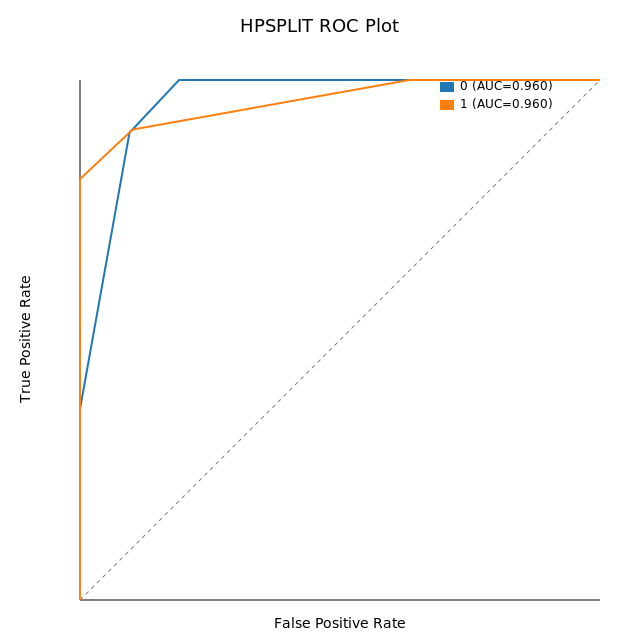

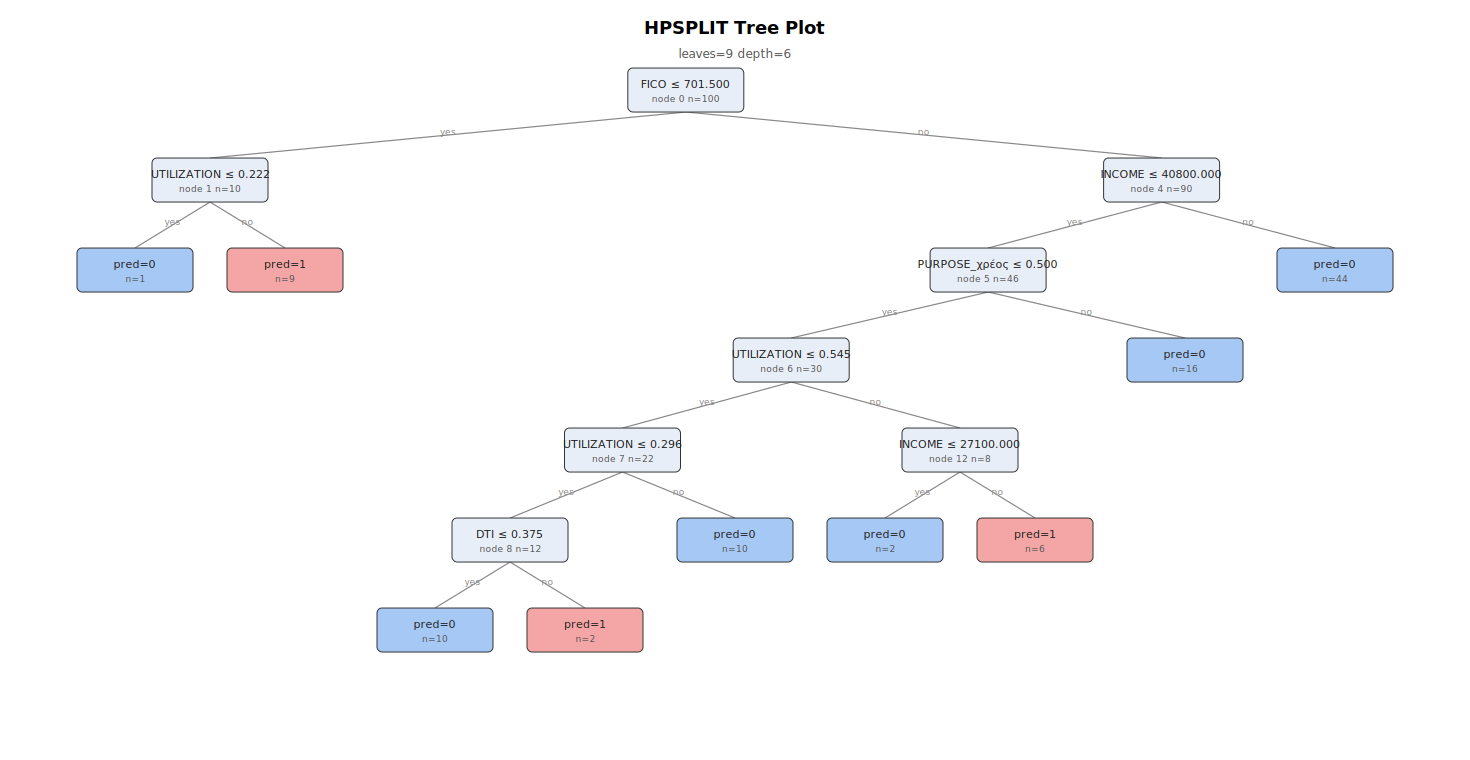

In [2]:
ODS GRAPHICS ON;

ΔΙΑΔΙΚΑΣΙΑ hpsplit ΔΕΔΟΜΕΝΑ=applicants seed=20260531
             PLOTS=(wholetree roc);
   ΚΛΑΣΗ default home purpose;
   ΜΟΝΤΕΛΟ default (EVENT='1') =
         dti utilization fico credit_age n_delinq
         loan_amount income home purpose;
   ΕΤΙΚΕΤΑ default = 'Αθέτηση' dti = 'Λόγος Χρέους προς Εισόδημα' utilization = 'Χρήση Πιστωτικού Ορίου'
         fico = 'Βαθμολογία FICO' credit_age = 'Ηλικία Πιστωτικού Ιστορικού'
         n_delinq = 'Αριθμός Πρόσφατων Καθυστερήσεων' loan_amount = 'Ποσό Δανείου'
         income = 'Εισόδημα' home = 'Ιδιοκτησία Κατοικίας' purpose = 'Σκοπός Δανείου';
   grow entropy;
   prune costcomplexity;
ΕΚΤΕΛΕΣΗ;

Τα **Στατιστικά Προσαρμογής** (ακρίβεια, ποσοστό εσφαλμένης ταξινόμησης, log loss) και το **ROC / AUC ανά κλάση** δείχνουν πόσο καθαρά το κλαδεμένο δέντρο διαχωρίζει τους αθετούντες από τους μη αθετούντες. Ο πίνακας **Σπουδαιότητας Μεταβλητών** κατατάσσει ποια χαρακτηριστικά καθοδηγούν τους διαχωρισμούς — εδώ κυριαρχούν το **FICO** και η **χρήση πιστωτικού ορίου**, ακολουθούμενα από το **εισόδημα** και τον **σκοπό δανείου**, ακριβώς οι μοχλοί που θα τόνιζε μια πιστωτική πολιτική. Το **διάγραμμα ολόκληρου δέντρου** παρακάτω παρουσιάζει τους επιλεγμένους διαχωρισμούς ως διάγραμμα κόμβων-συνδέσμων: κάθε εσωτερικός κόμβος δείχνει τον κανόνα του , και κάθε φύλλο χρωματίζεται σύμφωνα με την προβλεπόμενη κλάση του (κόκκινο = προβλεπόμενη αθέτηση, μπλε = προβλεπόμενη μη αθέτηση) και επισημαίνεται με το μέγεθος δείγματός του.

## 3. Εστίαση στους κύριους διαχωρισμούς και βαθμολόγηση κάθε αιτούντα

Το διάγραμμα ROC παραπάνω απεικονίζει την αντιστάθμιση μεταξύ σύλληψης αθετούντων και ψευδών συναγερμών· το AUC ποσοτικοποιεί τη συνολική ισχύ κατάταξης. Στη συνέχεια μεγεθύνουμε τα δύο πρώτα επίπεδα του δέντρου — τους διαχωρισμούς υψηλότερης πληροφορίας που ένας αναλυτής θα μετέτρεπε σε βασικούς κανόνες αναδοχής — και συλλαμβάνουμε βαθμολογίες ανά παρατήρηση σε ένα σύνολο δεδομένων εξόδου, ώστε να μπορούμε να ελέγξουμε τις προβλέψεις στη συνέχεια.


                                                 The HPSPLIT Procedure                                                  

Model Information
Response Variable         DEFAULT
Event Level               1
Split Criterion           Entropy
Pruning Method            Cost-Complexity
Random Seed               20260531
Number of Observations    100

Predictors
    1. DTI
    2. UTILIZATION
    3. FICO
    4. CREDIT_AGE
    5. N_DELINQ
    6. LOAN_AMOUNT
    7. INCOME
    8. HOME
    9. PURPOSE

Number of Leaves          9
Final Tree Depth          6

Fit Statistics
  accuracy                   0.960000
  misclass_rate              0.040000
  log_loss                   0.131399

ROC / AUC by Class
Class                               AUC
0                              0.960217
1                              0.960217

Variable Importance
Variable                     Importance       Relative
FICO                           0.334699       0.334699
UTILIZATION                    0.266873       0.26


NOTE: PROC HPSPLIT data=applicants

NOTE: HPSPLIT OUTPUT OUT= dataset written to ./work/04b37aaa-b4d7-47c8-864e-12bb2733e0bc/scored.avro
NOTE: ODS plot written: HPSplitZoomedTree.svg
NOTE: PROC HPSPLIT completed.
NOTE: PROC PRINT data=scored

NOTE: PROC PRINT completed: 10 observations printed, 3 variables


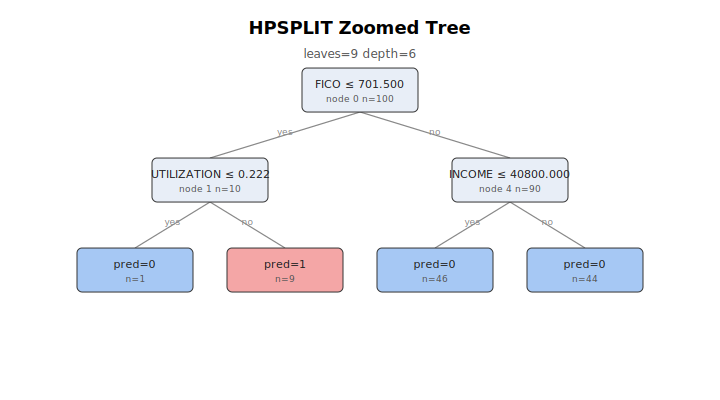

In [3]:
ΔΙΑΔΙΚΑΣΙΑ hpsplit ΔΕΔΟΜΕΝΑ=applicants seed=20260531
             PLOTS=zoomedtree(nodes=('0') depth=2);
   ΚΛΑΣΗ default home purpose;
   ΜΟΝΤΕΛΟ default (EVENT='1') =
         dti utilization fico credit_age n_delinq
         loan_amount income home purpose;
   grow entropy;
   prune costcomplexity;
   ΕΞΟΔΟΣ out=scored;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=scored(obs=10) ΕΤΙΚΕΤΑ;
   ΜΕΤΑΒΛΗΤΗ p_default1 _node_ _leaf_;
   ΕΤΙΚΕΤΑ p_default1 = 'Πιθανότητα Αθέτησης' _node_ = 'Κόμβος' _leaf_ = 'Φύλλο';
ΕΚΤΕΛΕΣΗ;

Το διάγραμμα `zoomedtree` μεγεθύνει τα δύο πρώτα επίπεδα του δέντρου — τους διαχωρισμούς υψηλότερης πληροφορίας που ένας αναλυτής θα μετέτρεπε σε βασικούς κανόνες αναδοχής. Το σύνολο δεδομένων `OUTPUT OUT=` φέρει την προβλεπόμενη πιθανότητα αθέτησης κάθε αιτούντα (`P_DEFAULT1`) καθώς και τον ανατεθειμένο κόμβο και φύλλο (`_NODE_`, `_LEAF_`), ώστε οι ομάδες κινδύνου και ελέγχου να μπορούν να ανιχνεύσουν οποιαδήποτε ατομική απόφαση πίσω μέσα από το δέντρο και να κατατάξουν τους αιτούντες κατά μοντελοποιημένο κίνδυνο.

## 4. Εξαγωγή αναπτύξιμου κώδικα βαθμολόγησης

Η αξία ενός ερμηνεύσιμου μοντέλου είναι ότι μπορεί να διανεμηθεί. Το `CODE FILE=` γράφει ένα αυτόνομο βήμα DATA — μια εμφωλευμένη αλυσίδα διαχωρισμών `IF/THEN` που καταλήγει σε μια προβλεπόμενη πιθανότητα και κλάση αθέτησης — που αναπαράγει τη βαθμολογία του δέντρου για οποιοδήποτε νέο αρχείο αίτησης, χωρίς να απαιτείται διακομιστής μοντέλου.

In [4]:
ΔΙΑΔΙΚΑΣΙΑ hpsplit ΔΕΔΟΜΕΝΑ=applicants seed=20260531;
   ΚΛΑΣΗ default home purpose;
   ΜΟΝΤΕΛΟ default (EVENT='1') =
         dti utilization fico credit_age n_delinq
         loan_amount income home purpose;
   grow entropy;
   prune costcomplexity;
   code FILE='credit_scorecard.sas';
ΕΚΤΕΛΕΣΗ;


                                                 The HPSPLIT Procedure                                                  

Model Information
Response Variable         DEFAULT
Event Level               1
Split Criterion           Entropy
Pruning Method            Cost-Complexity
Random Seed               20260531
Number of Observations    100

Predictors
    1. DTI
    2. UTILIZATION
    3. FICO
    4. CREDIT_AGE
    5. N_DELINQ
    6. LOAN_AMOUNT
    7. INCOME
    8. HOME
    9. PURPOSE

Number of Leaves          9
Final Tree Depth          6

Fit Statistics
  accuracy                   0.960000
  misclass_rate              0.040000
  log_loss                   0.131399

ROC / AUC by Class
Class                               AUC
0                              0.960217
1                              0.960217

Variable Importance
Variable                     Importance       Relative
FICO                           0.334699       0.334699
UTILIZATION                    0.266873       0.26


NOTE: PROC HPSPLIT data=applicants

NOTE: PROC HPSPLIT completed.


## Ερμηνεία των αποτελεσμάτων

Το κλαδεμένο δέντρο εντροπίας δίνει στην ομάδα κινδύνου μια συμπαγή, ελέγξιμη πιστωτική κάρτα βαθμολόγησης:

- **Οι διαχωρισμοί κωδικοποιούν πολιτική.** Οι κυρίαρχοι διαχωρισμοί — στο FICO και στη χρήση ανακυκλούμενου πιστωτικού ορίου, έπειτα στο εισόδημα και στον σκοπό δανείου — είναι ακριβώς τα όρια που μια ομάδα αναδοχής θα μπορούσε να μετατρέψει σε αυστηρούς κανόνες αποκοπής. Το διάγραμμα ολόκληρου δέντρου παραθέτει κάθε συνθήκη διαχωρισμού και φύλλο σε ένα διάγραμμα.
- Το **κλάδεμα κόστους-πολυπλοκότητας** εμποδίζει το δέντρο να απομνημονεύσει θόρυβο· τα στατιστικά προσαρμογής (ακρίβεια, ποσοστό εσφαλμένης ταξινόμησης, log loss) συνοψίζουν πόσο καθαρά διαχωρίζει τις δύο κλάσεις.
- Η **σπουδαιότητα μεταβλητών και το ROC/AUC** δικαιολογούν ποια χαρακτηριστικά κερδίζουν θέση στην κάρτα βαθμολόγησης και τεκμηριώνουν τη διακριτική της ισχύ για τη διακυβέρνηση κινδύνου μοντέλου.
- Το **`CODE FILE=` το καθιστά λειτουργικό** — ο εκδιδόμενος κώδικας DATA step βαθμολογεί νέους αιτούντες πανομοιότυπα με αυτή την εκτέλεση, ώστε το μοντέλο που κατασκευάστηκε να είναι ακριβώς το μοντέλο που τίθεται σε παραγωγική λειτουργία.

Σε ένα μικρό βιβλίο αιτούντων το δέντρο προσαρμόζεται στενά στα δεδομένα εκπαίδευσης· σε παραγωγή θα το καλλιεργούσατε στο πλήρες χαρτοφυλάκιο, θα κρατούσατε μια διαμέριση επικύρωσης, θα βαθμονομούσατε το όριο αποκοπής πιθανότητας στα οικονομικά αναμενόμενης ζημίας της τράπεζας (το κόστος μιας χαμένης αθέτησης έναντι ενός απορριφθέντος καλού πελάτη) αντί για ένα απλοϊκό 0.5, και θα ανανεώνατε το δέντρο καθώς μεταβάλλεται η σύνθεση του χαρτοφυλακίου.